# Notebook 06 — Model Development

**Target:** Predict `fare_amount` (regression)  
**Dataset:** `features_v2` — 300,000 NYC Yellow Taxi trips (March 2016)  
**Models:**
1. Baseline — Median predictor
2. Linear Regression
3. Gradient Boosted Trees (GBT via scikit-learn)

**Note:** `fare_per_mile` is dropped from features — it is derived directly from `fare_amount / trip_distance` and would cause data leakage.

## 1. Setup

In [1]:
import subprocess, sys

pkgs = ["mlflow", "xgboost"]
for pkg in pkgs:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages ready.")

All packages ready.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import joblib
import os
import glob
import json

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor

SEED = 42
np.random.seed(SEED)

# Fix: MLflow URL-encodes spaces in paths on Windows — pin tracking to a local relative dir
os.makedirs("mlruns", exist_ok=True)
mlflow.set_tracking_uri("mlruns")
mlflow.set_experiment("taxi_fare_prediction")

print("Imports done.")

C:\Users\Owais Khalid\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/08 13:47:46 INFO mlflow.tracking.fluent: Experiment with name 'taxi_fare_prediction' does not exist. Creating a new experiment.


Imports done.


## 2. Load Data

In [3]:
DATA_DIR = "data/features_v2/"

parquet_files = glob.glob(os.path.join(DATA_DIR, "*.parquet"))
print(f"Found {len(parquet_files)} parquet file(s): {parquet_files}")

df = pd.read_parquet(parquet_files[0])
print(f"Shape: {df.shape}")
df.head()

Found 1 parquet file(s): ['data/features_v2\\part-00000-tid-70725626841109002-846b0f25-7c4d-490f-ad92-4090e25f6fac-512-1.c000.snappy.parquet']
Shape: (300000, 11)


,tpep_pickup_datetime,tpep_dropoff_datetime,pickup_hour,pickup_day_of_week,trip_distance,trip_duration_minutes,passenger_count,fare_amount,fare_per_mile,is_weekend,avg_speed_mph
0,2016-03-01 00:00:00,2016-03-01 00:07:55,0,3,2.50,7.916667,1,9.0,3.600000,0,18.947368
1,2016-03-01 00:00:00,2016-03-01 00:11:06,0,3,2.90,11.100000,1,11.0,3.793103,0,15.675676
2,2016-03-01 00:00:00,2016-03-01 00:31:06,0,3,19.98,31.100000,2,54.5,2.727728,0,38.546624
3,2016-03-01 00:00:01,2016-03-01 00:02:03,0,3,0.54,2.033333,2,4.0,7.407407,0,15.934426
4,2016-03-01 00:00:01,2016-03-01 00:05:00,0,3,0.70,4.983333,1,5.5,7.857143,0,8.428094


In [4]:
# Sanity checks
print("Dtypes:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())
print("\nTarget (fare_amount) stats:")
print(df["fare_amount"].describe())

Dtypes:
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
pickup_hour                       int32
pickup_day_of_week                int32
trip_distance                   float64
trip_duration_minutes           float64
passenger_count                   int32
fare_amount                     float64
fare_per_mile                   float64
is_weekend                        int32
avg_speed_mph                   float64
dtype: object

Null counts:
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
pickup_hour              0
pickup_day_of_week       0
trip_distance            0
trip_duration_minutes    0
passenger_count          0
fare_amount              0
fare_per_mile            0
is_weekend               0
avg_speed_mph            0
dtype: int64

Target (fare_amount) stats:
count    300000.000000
mean         12.266167
std          10.503451
min           0.000000
25%           6.500000
50%           9.000000
75%          13.500000
max         819.500000
N

## 3. Prepare Features

In [5]:
# Drop leakage column and datetime columns not usable as raw features
FEATURE_COLS = [
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "avg_speed_mph"
]
TARGET = "fare_amount"

# Drop rows with nulls in feature or target cols
df_clean = df[FEATURE_COLS + [TARGET]].dropna()

# Remove clearly invalid rows (negative fare or distance)
df_clean = df_clean[(df_clean[TARGET] > 0) & (df_clean["trip_distance"] > 0)]

print(f"Rows after cleaning: {len(df_clean):,}")
print(f"Features: {FEATURE_COLS}")
print(f"Target: {TARGET}")

Rows after cleaning: 298,567
Features: ['trip_distance', 'trip_duration_minutes', 'passenger_count', 'pickup_hour', 'pickup_day_of_week', 'is_weekend', 'avg_speed_mph']
Target: fare_amount


## 4. Train / Validation / Test Split

In [6]:
X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET].values

# 70% train, 15% val, 15% test — fixed seed for reproducibility
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"Train : {len(X_train):,} rows")
print(f"Val   : {len(X_val):,} rows")
print(f"Test  : {len(X_test):,} rows")

Train : 208,996 rows
Val   : 44,785 rows
Test  : 44,786 rows


## 5. Helper — Evaluate Model

In [7]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:30s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

## 6. Model 1 — Baseline (Median Predictor)

In [8]:
with mlflow.start_run(run_name="baseline_median"):
    baseline = DummyRegressor(strategy="median")
    baseline.fit(X_train, y_train)

    val_pred_baseline = baseline.predict(X_val)
    metrics_baseline = evaluate("Baseline (Median)", y_val, val_pred_baseline)

    mlflow.log_params({"strategy": "median", "seed": SEED})
    mlflow.log_metrics(metrics_baseline)
    mlflow.sklearn.log_model(baseline, artifact_path="model")

    run_id_baseline = mlflow.active_run().info.run_id
    print(f"Run ID: {run_id_baseline}")

2026/04/08 13:47:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Baseline (Median)               RMSE=10.8082  MAE=5.8868  R²=-0.1016


2026/04/08 13:47:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: d130f3dd8f8e4c6a8d7795188e01741a


## 7. Model 2 — Linear Regression

In [9]:
with mlflow.start_run(run_name="linear_regression"):
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    val_pred_lr = lr.predict(X_val)
    metrics_lr = evaluate("Linear Regression", y_val, val_pred_lr)

    mlflow.log_params({"model": "LinearRegression", "seed": SEED})
    mlflow.log_metrics(metrics_lr)
    mlflow.sklearn.log_model(lr, artifact_path="model")

    run_id_lr = mlflow.active_run().info.run_id
    print(f"Run ID: {run_id_lr}")

2026/04/08 13:48:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression               RMSE=10.1402  MAE=6.2804  R²=0.0304


2026/04/08 13:48:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: 669615c7f083403883cd391aca5be365


## 8. Model 3 — Gradient Boosted Trees

In [10]:
GBT_PARAMS = {
    "n_estimators": 200,
    "max_depth": 5,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "random_state": SEED
}

with mlflow.start_run(run_name="gradient_boosted_trees"):
    gbt = GradientBoostingRegressor(**GBT_PARAMS)
    gbt.fit(X_train, y_train)

    val_pred_gbt = gbt.predict(X_val)
    metrics_gbt = evaluate("Gradient Boosted Trees", y_val, val_pred_gbt)

    mlflow.log_params({**GBT_PARAMS, "features": FEATURE_COLS, "data_version": "taxi_features_v2:1"})
    mlflow.log_metrics(metrics_gbt)
    mlflow.sklearn.log_model(gbt, artifact_path="model")

    run_id_gbt = mlflow.active_run().info.run_id
    print(f"Run ID: {run_id_gbt}")

2026/04/08 13:50:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Gradient Boosted Trees          RMSE=2.3521  MAE=0.4763  R²=0.9478


2026/04/08 13:50:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID: 566dbd70bf4b4e16b78009123d346dff


## 9. Validation Summary

                           rmse     mae      r2
Model                                          
Baseline (Median)       10.8082  5.8868 -0.1016
Linear Regression       10.1402  6.2804  0.0304
Gradient Boosted Trees   2.3521  0.4763  0.9478


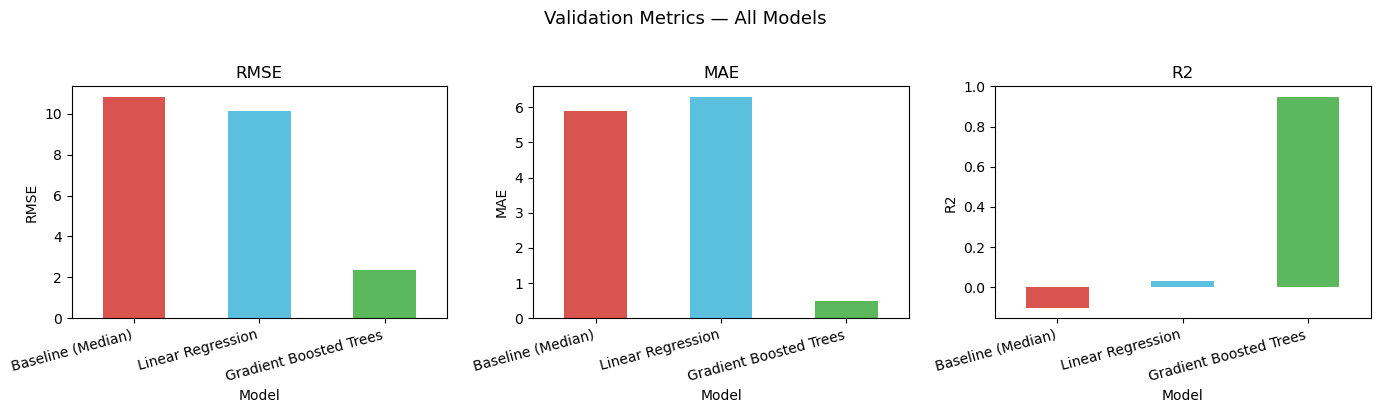

Saved: outputs/06_model_comparison.png


In [11]:
results = pd.DataFrame([
    {"Model": "Baseline (Median)",       **metrics_baseline},
    {"Model": "Linear Regression",       **metrics_lr},
    {"Model": "Gradient Boosted Trees",  **metrics_gbt},
]).set_index("Model")

print(results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["rmse", "mae", "r2"]):
    results[metric].plot(kind="bar", ax=ax, color=["#d9534f", "#5bc0de", "#5cb85c"])
    ax.set_title(metric.upper())
    ax.set_xticklabels(results.index, rotation=15, ha="right")
    ax.set_ylabel(metric.upper())
plt.suptitle("Validation Metrics — All Models", fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/06_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: outputs/06_model_comparison.png")

## 10. Feature Importance (GBT)

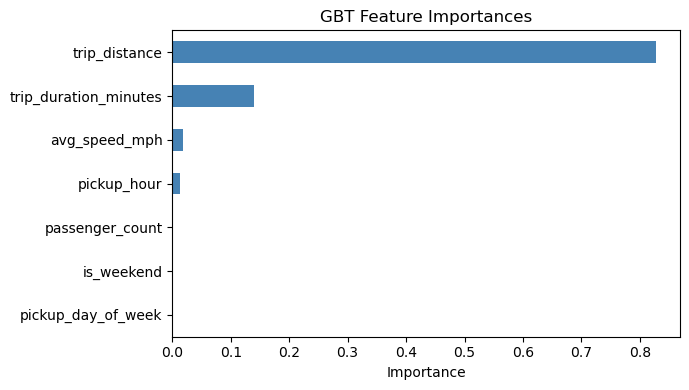

Saved: outputs/06_feature_importance.png


In [12]:
importances = pd.Series(gbt.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("GBT Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("outputs/06_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: outputs/06_feature_importance.png")

## 11. Save Best Model

In [13]:
os.makedirs("model", exist_ok=True)
joblib.dump(gbt, "model/taxi_fare_gbt.pkl")
joblib.dump(lr,  "model/taxi_fare_lr.pkl")

metadata = {
    "model_name": "taxi_fare_predictor_gbt",
    "version": "1",
    "algorithm": "GradientBoostingRegressor",
    "data_version": "taxi_features_v2:1",
    "features": FEATURE_COLS,
    "target": TARGET,
    "random_seed": SEED,
    "params": GBT_PARAMS,
    "val_metrics": metrics_gbt,
    "leakage_dropped": ["fare_per_mile"],
    "train_rows": len(X_train),
    "val_rows": len(X_val),
    "test_rows": len(X_test)
}
with open("model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model/taxi_fare_gbt.pkl")
print("Saved model/metadata.json")
print(json.dumps(metadata, indent=2))

Saved model/taxi_fare_gbt.pkl
Saved model/metadata.json
{
  "model_name": "taxi_fare_predictor_gbt",
  "version": "1",
  "algorithm": "GradientBoostingRegressor",
  "data_version": "taxi_features_v2:1",
  "features": [
    "trip_distance",
    "trip_duration_minutes",
    "passenger_count",
    "pickup_hour",
    "pickup_day_of_week",
    "is_weekend",
    "avg_speed_mph"
  ],
  "target": "fare_amount",
  "random_seed": 42,
  "params": {
    "n_estimators": 200,
    "max_depth": 5,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "random_state": 42
  },
  "val_metrics": {
    "rmse": 2.352059818326011,
    "mae": 0.47632436040775994,
    "r2": 0.9478310729220417
  },
  "leakage_dropped": [
    "fare_per_mile"
  ],
  "train_rows": 208996,
  "val_rows": 44785,
  "test_rows": 44786
}
